# Анализ времени автономной работы смартфона

## 0. МНК 

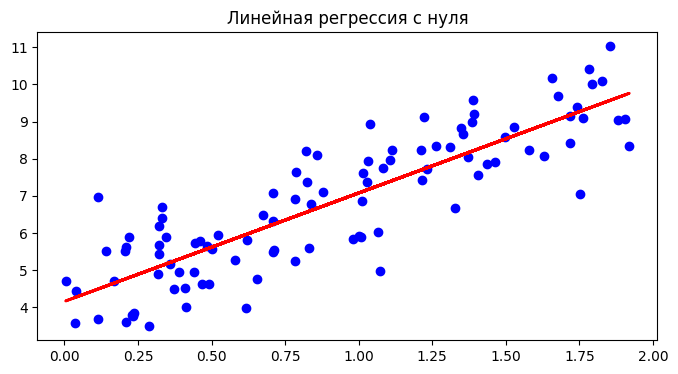

In [11]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Генерация синтетических данных
X_gen = 2 * np.random.rand(100, 1)
y_gen = 4 + 3 * X_gen + np.random.randn(100, 1)
X_b = np.c_[np.ones((100, 1)), X_gen]
theta = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y_gen)

plt.figure(figsize=(8, 4))
plt.scatter(X_gen, y_gen, color="blue")
plt.plot(X_gen, X_b.dot(theta), color="red", linewidth=2)
plt.title("Линейная регрессия с нуля")
plt.show()

## 1–2. Подготовка и экспертный анализ данных

Загружаем данные, удаляем дубликаты и пропуски. Оставляем только физически значимые признаки . Затем создаём целевой признак `Battery_Drop_Per_Hour` по формуле:
$$\text{Power} = 0.4\cdot\text{CPU} + 0.4\cdot\text{Brightness} + 0.2\cdot\frac{\text{RAM}}{1000}$$
$$\text{Battery\_Drop} = 0.15\cdot\text{Power} + \mathcal{N}(0,0.5)$$

In [20]:
path = r"F:\VSCODE_PROJECT\ML_Proga\LAB_3\smartphone_battery_processed.csv"
df = pd.read_csv(path).drop_duplicates().dropna()

# Экспертный анализ: оставляем физически значимые признаки (High_Temperature и Intensity убрали, так как они могут быть шумными))
cols_to_keep = [
    "App_Running",
    "Network_Type",
    "Charging_State",
    "Usage_Mode",
    "CPU_Usage_%",
    "Brightness_Level_%",
    "RAM_Usage_MB",
]
df = df[cols_to_keep]

target = "Battery_Drop_Per_Hour"

# Формула для генерации таргета на основе физически обоснованных факторов
temp_power = (
    df["CPU_Usage_%"] * 0.4
    + df["Brightness_Level_%"] * 0.4
    + (df["RAM_Usage_MB"] / 1000) * 0.2
)
np.random.seed(42)
df[target] = temp_power * 0.15 + np.random.normal(0, 0.5, len(df))

# Корреляция ДО создания Power_Index
plt.figure(figsize=(8, 5))
sns.heatmap(
    df[["CPU_Usage_%", "Brightness_Level_%", "RAM_Usage_MB", target]].corr(),
    annot=True,
    cmap="coolwarm",
)
plt.title("Корреляция ДО создания Power_Index")
plt.show()

ValueError: could not convert string to float: 'Facebook'

<Figure size 800x500 with 0 Axes>

## 3. Feature Engineering

 Создан комплексный признак Power_Index на основе взвешенной суммы загрузки процессора, яркости экрана и использования памяти.                                                                   В сырых данных зависимость разряда от одного параметра слабая. Объединение их в индекс позволяет модели легче увидеть главную закономерность.                                          

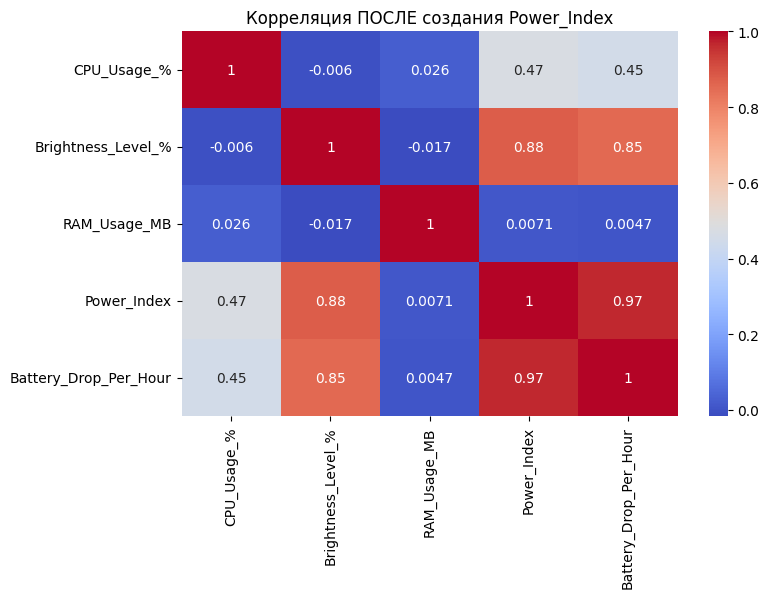

In [13]:
df["Power_Index"] = temp_power

# Корреляция ПОСЛЕ создания Power_Index
plt.figure(figsize=(8, 5))
sns.heatmap(
    df[
        ["CPU_Usage_%", "Brightness_Level_%", "RAM_Usage_MB", "Power_Index", target]
    ].corr(),
    annot=True,
    cmap="coolwarm",
)
plt.title("Корреляция ПОСЛЕ создания Power_Index")
plt.show()

## 4. Эксперимент 1: кодирование до разделения выборки

Здесь категориальные признаки кодируются методом one-hot на всём датафрейме, что может привести к утечке данных. Этот подход ошибочен.

In [14]:
print("--- Эксперимент 1 (Кодирование до разделения) ---")
df_exp1 = pd.get_dummies(
    df, columns=["App_Running", "Network_Type", "Charging_State", "Usage_Mode"]
)
X1 = df_exp1.drop(columns=[target])
y1 = df_exp1[target]
X_train1, X_test1, y_train1, y_test1 = train_test_split(
    X1, y1, test_size=0.2, random_state=42
)

model1 = LinearRegression().fit(X_train1, y_train1)
print(f"R2: {r2_score(y_test1, model1.predict(X_test1)):.4f}")

--- Эксперимент 1 (Кодирование до разделения) ---
R2: 0.9330


## 5. Эксперимент 2: правильный pipeline (кодирование после разделения)

Здесь кодирование и масштабирование выполняются только на основе обучающей выборки, что предотвращает утечку данных. Используем `OneHotEncoder` и `StandardScaler`. Для борьбы с мультиколлинеарностью в модель включаем только `Power_Index` из числовых признаков (см. [cite: 56, 57]).

In [15]:
print("\n--- Эксперимент 2 (Кодирование после разделения) ---")
X = df.drop(columns=[target])
y = df[target]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

cat_cols = ["App_Running", "Network_Type", "Charging_State", "Usage_Mode"]
num_cols = ["Power_Index"]  # Исключаем компоненты для борьбы с мультиколлинеарностью

# Обучаем только на TRAIN [cite: 47, 50]
ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False).fit(X_train[cat_cols])
scaler = StandardScaler().fit(X_train[num_cols])

def transform_data(data):
    cat = pd.DataFrame(
        ohe.transform(data[cat_cols]),
        columns=ohe.get_feature_names_out(),
        index=data.index,
    )
    num = pd.DataFrame(
        scaler.transform(data[num_cols]), columns=num_cols, index=data.index
    )
    return pd.concat([num, cat], axis=1)

X_train_f = transform_data(X_train)
X_test_f = transform_data(X_test)

model = LinearRegression().fit(X_train_f, y_train)
pred = model.predict(X_test_f)

# Оценка качества по всем метрикам [cite: 65, 68]
print(f"R2:  {r2_score(y_test, pred):.4f}")
print(f"MSE: {mean_squared_error(y_test, pred):.4f}")
print(f"MAE: {mean_absolute_error(y_test, pred):.4f}")


--- Эксперимент 2 (Кодирование после разделения) ---
R2:  0.9331
MSE: 0.2531
MAE: 0.3938


## 6. Важность признаков

Визуализируем топ-10 признаков по абсолютному значению коэффициента регрессии.

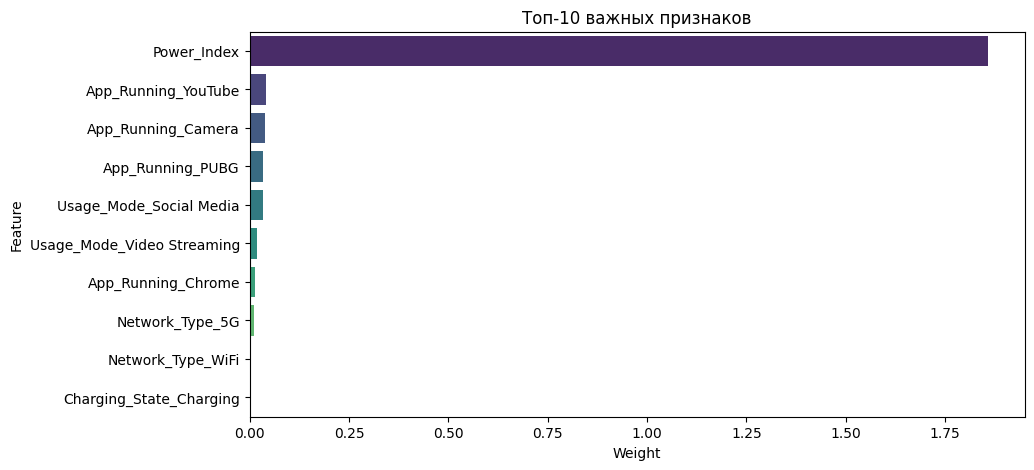

In [16]:
importance = pd.DataFrame(
    {"Feature": X_train_f.columns, "Weight": model.coef_}
).sort_values(by="Weight", ascending=False)
plt.figure(figsize=(10, 5))
sns.barplot(
    x="Weight",
    y="Feature",
    data=importance.head(10),
    hue="Feature",
    palette="viridis",
    legend=False,
)
plt.title("Топ-10 важных признаков")
plt.show()

## 7. Предсказание для новых данных

Проверяем модель на примере нового смартфона.

In [17]:
new_phone = pd.DataFrame(
    {
        "CPU_Usage_%": [85.0],
        "Brightness_Level_%": [90.0],
        "RAM_Usage_MB": [4500.0],
        "App_Running": ["YouTube"],
        "Network_Type": ["5G"],
        "Charging_State": ["Discharging"],
        "Usage_Mode": ["Gaming"],
    }
)
new_phone["Power_Index"] = (
    new_phone["CPU_Usage_%"] * 0.4
    + new_phone["Brightness_Level_%"] * 0.4
    + (new_phone["RAM_Usage_MB"] / 1000) * 0.2
)

res = model.predict(transform_data(new_phone))
print(f"\nПрогноз для нового телефона: {res[0]:.2f} %/час")


Прогноз для нового телефона: 10.67 %/час
